<a href="https://colab.research.google.com/github/social410/data_science/blob/master/Spam_Email_Detector_using_Scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns




In [12]:
# Load the dataset
data = '/content/drive/My Drive/Colab Notebooks/spam.csv'

data = pd.read_csv(data)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [14]:
# Splt dataset into training and testing sets
X = data.drop('spam', axis=1)
y = data['spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Train the logistic regression model to classify emails as spam or not spam
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test) # Predict

print(X_test)


      word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
3683            0.00                0.0           0.00           0.0   
4412            0.71                0.0           0.71           0.0   
2584            0.00                0.0           0.91           0.0   
69              0.00                0.0           0.00           0.0   
1844            0.00                0.0           0.54           0.0   
...              ...                ...            ...           ...   
1068            0.16                0.0           0.67           0.0   
4351            0.00                0.0           0.00           0.0   
3027            0.00                0.0           1.60           0.0   
3455            0.75                0.0           0.00           0.0   
1898            0.00                2.4           0.00           0.0   

      word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
3683           0.00            0.00              0.00     

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# Evaluate model using Accuracy. confusion matrix, precision, recall and f1 score
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.9250814332247557
Confusion Matrix:
[[500  31]
 [ 38 352]]
Precision: 0.9190600522193212
Recall: 0.9025641025641026
F1 Score: 0.9107373868046572


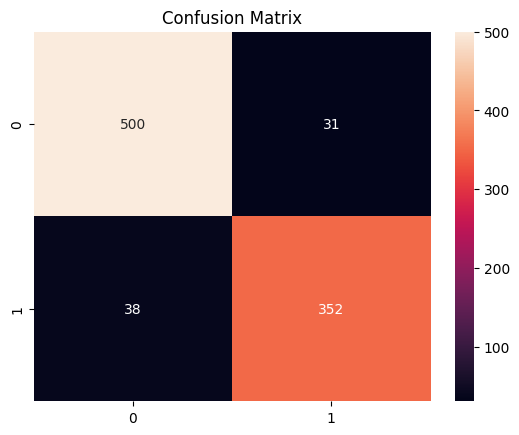

In [18]:
# Visualize the confusion matrix using seaborns heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel('Predicted')
# plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()